# Tác động của Streamer Trung tâm và Streamer Cầu nối đến Cấu trúc Cộng đồng trên Twitch

Notebook Google Colab — phân tích mạng xã hội trên dataset Twitch ENGB
(musae_ENGB_edges.csv, musae_ENGB_target.csv — 7,126 streamer, 35,324 cạnh).

Cấu trúc notebook theo đúng đề cương báo cáo:
1. Cài đặt & Upload dữ liệu
2. Đọc dữ liệu & Thống kê mô tả mạng lưới
3. Chỉ số Độ trung tâm
4. Phát hiện Cộng đồng: Louvain vs Girvan-Newman vs Random
5. Phân loại Streamer Trung tâm vs Streamer Cầu nối
6. Đồng nhất Thuộc tính / Homophily
7. Thử nghiệm Phân mảnh Mạng — Robustness Test
8. Trực quan hóa Mạng lưới: NetworkX / Gephi / Cytoscape

### Phiên bản revised — methodology nhất quán với câu hỏi nghiên cứu
- Phân loại **Provincial Hub** bằng `within-module z >= 2.5` và `Participation <= 0.30`.
- Phân loại **Community Bridge** là non-hub có `Participation > 0.62`; Betweenness chỉ dùng để đánh giá/rank mức độ bridging, không dùng để định nghĩa Hub.
- Robustness test xóa **đúng các node đã được classify Hub vs Bridge**, với **cùng số node bị xóa** ở hai nhóm.
- Với `mature`, dùng **attribute assortativity** + permutation baseline; với `views`, dùng **eta-squared theo community** trên `log1p(views)` + random-partition baseline.
- Bổ sung sensitivity check cho approximate Betweenness.
- Sửa role mapping ở visualization, bỏ các cell trực quan trùng/fragile và cập nhật terminology.


## 0. Cài đặt thư viện

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## 0.1. Upload dữ liệu

In [ ]:
EDGES_PATH = "musae_ENGB_edges.csv"
TARGET_PATH = "musae_ENGB_target.csv"

if not (os.path.exists(EDGES_PATH) and os.path.exists(TARGET_PATH)):
    try:
        from google.colab import files
        print("Vui long chon 2 file: musae_ENGB_edges.csv va musae_ENGB_target.csv")
        uploaded = files.upload()
    except ImportError:
        print("Khong phai moi truong Colab va khong tim thay file CSV trong thu muc hien tai.")
        print("Hay dat musae_ENGB_edges.csv va musae_ENGB_target.csv cung thu muc voi notebook.")
else:
    print("Da tim thay san 2 file CSV trong thu muc hien tai.")

Vui long chon 2 file: musae_ENGB_edges.csv va musae_ENGB_target.csv


Saving musae_ENGB_target.csv to musae_ENGB_target.csv
Saving musae_ENGB_edges.csv to musae_ENGB_edges.csv


## 1. Đọc dữ liệu & Thống kê mô tả mạng lưới
### (Dữ liệu & Tiền xử lý — Thống kê mô tả mạng lưới)

In [ ]:
edges = pd.read_csv(EDGES_PATH)
target = pd.read_csv(TARGET_PATH)

target["new_id"] = target["new_id"].astype(int)
target["mature"] = target["mature"].astype(bool)
target["partner"] = target["partner"].astype(bool)

G = nx.Graph()
G.add_nodes_from(target["new_id"].tolist())
G.add_edges_from(list(zip(edges["from"], edges["to"])))

attr_dict = target.set_index("new_id")[["days", "mature", "views", "partner"]].to_dict("index")
nx.set_node_attributes(G, attr_dict)

print(f"So nut (N): {G.number_of_nodes()}")
print(f"So canh (M): {G.number_of_edges()}")

So nut (N): 7126
So canh (M): 35324


In [ ]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
avg_degree = 2 * n_edges / n_nodes

components = list(nx.connected_components(G))
lcc_nodes = max(components, key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

try:
    diameter_lcc = nx.diameter(G_lcc)
except Exception:
    from networkx.algorithms.approximation import diameter as approx_diameter
    diameter_lcc = approx_diameter(G_lcc)

avg_clustering = nx.average_clustering(G)

stats = {
    "So nut (N)": n_nodes,
    "So canh (M)": n_edges,
    "Bac trung binh": round(avg_degree, 3),
    "So thanh phan lien thong": len(components),
    "Kich thuoc LCC (nut)": len(lcc_nodes),
    "Ty le LCC/N": round(len(lcc_nodes) / n_nodes, 4),
    "Duong kinh (tren LCC)": diameter_lcc,
    "He so gom cum trung binh (C)": round(avg_clustering, 4),
}

print("BẢNG THỐNG KÊ MÔ TẢ MẠNG LƯỚI")
df_stats = pd.DataFrame(list(stats.items()), columns=["Chi so", "Gia tri"])
df_stats

BẢNG THỐNG KÊ MÔ TẢ MẠNG LƯỚI


,Chi so,Gia tri
0,So nut (N),7126.0000
1,So canh (M),35324.0000
2,Bac trung binh,9.9140
3,So thanh phan lien thong,1.0000
4,Kich thuoc LCC (nut),7126.0000
5,Ty le LCC/N,1.0000
6,Duong kinh (tren LCC),10.0000
7,He so gom cum trung binh (C),0.1309


## 2. Chỉ số Độ trung tâm (Centrality Metrics)

Đồ thị có khoảng 7,126 nút / 35,324 cạnh nên Betweenness Centrality được tính **xấp xỉ bằng node sampling** để giảm chi phí tính toán. Notebook dùng `k=800` cho phân tích chính và bổ sung sensitivity check với nhiều giá trị `k` để kiểm tra độ ổn định của nhóm node đứng đầu.

Lưu ý: Betweenness là một chỉ số **structural brokerage/shortest-path importance**. Nó không được dùng thay thế định nghĩa Hub/Bridge ở phần phân loại vai trò.


In [ ]:
BETWEENNESS_K = min(800, G.number_of_nodes())

print("Dang tinh Degree Centrality...")
degree_c = nx.degree_centrality(G)

print(f"Dang tinh Betweenness Centrality (xap xi, k={BETWEENNESS_K})...")
t0 = time.time()
betweenness_c = nx.betweenness_centrality(
    G, k=BETWEENNESS_K, seed=RANDOM_SEED, normalized=True
)
print(f"  Xong sau {time.time() - t0:.1f}s")

print("Dang tinh PageRank...")
pagerank = nx.pagerank(G)

centrality_df = pd.DataFrame({"node": list(G.nodes())})
centrality_df["degree_centrality"] = centrality_df["node"].map(degree_c)
centrality_df["betweenness_centrality"] = centrality_df["node"].map(betweenness_c)
centrality_df["pagerank"] = centrality_df["node"].map(pagerank)
centrality_df["degree_raw"] = centrality_df["node"].map(dict(G.degree()))

print("\n===== TOP 10 THEO DEGREE CENTRALITY =====")
print(centrality_df.sort_values("degree_centrality", ascending=False).head(10)
      [["node", "degree_raw", "degree_centrality"]].to_string(index=False))

print("\n===== TOP 10 THEO BETWEENNESS CENTRALITY =====")
print(centrality_df.sort_values("betweenness_centrality", ascending=False).head(10)
      [["node", "betweenness_centrality"]].to_string(index=False))

print("\n===== TOP 10 THEO PAGERANK =====")
print(centrality_df.sort_values("pagerank", ascending=False).head(10)
      [["node", "pagerank"]].to_string(index=False))

# ------------------------------------------------------------
# Sensitivity check cho approximate Betweenness
# So sánh overlap của Top-N nodes giữa k=400/800/1600 (nếu khả thi).
# ------------------------------------------------------------
RUN_BETWEENNESS_SENSITIVITY = True
SENSITIVITY_K_VALUES = [k for k in [400, 800, 1600] if k <= G.number_of_nodes()]
TOP_N_SENSITIVITY = 20

betweenness_sensitivity_df = pd.DataFrame()
betweenness_overlap_df = pd.DataFrame()

if RUN_BETWEENNESS_SENSITIVITY:
    sensitivity_scores = {}
    for k in SENSITIVITY_K_VALUES:
        if k == BETWEENNESS_K:
            scores = betweenness_c
        else:
            print(f"Sensitivity: tinh Betweenness voi k={k}...")
            scores = nx.betweenness_centrality(
                G, k=k, seed=RANDOM_SEED, normalized=True
            )
        sensitivity_scores[k] = scores

    betweenness_sensitivity_df = pd.DataFrame({"node": list(G.nodes())})
    for k, scores in sensitivity_scores.items():
        betweenness_sensitivity_df[f"betweenness_k{k}"] = (
            betweenness_sensitivity_df["node"].map(scores)
        )

    top_sets = {
        k: set(sorted(scores, key=scores.get, reverse=True)[:TOP_N_SENSITIVITY])
        for k, scores in sensitivity_scores.items()
    }
    rows = []
    for i, k1 in enumerate(SENSITIVITY_K_VALUES):
        for k2 in SENSITIVITY_K_VALUES[i + 1:]:
            inter = len(top_sets[k1] & top_sets[k2])
            union = len(top_sets[k1] | top_sets[k2])
            rows.append({
                "k_1": k1,
                "k_2": k2,
                f"Top_{TOP_N_SENSITIVITY}_overlap_count": inter,
                f"Top_{TOP_N_SENSITIVITY}_overlap_pct": round(100 * inter / TOP_N_SENSITIVITY, 1),
                "Jaccard": round(inter / union, 3) if union else 1.0,
            })
    betweenness_overlap_df = pd.DataFrame(rows)
    print("\n===== BETWEENNESS SENSITIVITY: TOP-N OVERLAP =====")
    display(betweenness_overlap_df)


Dang tinh Degree Centrality...
Dang tinh Betweenness Centrality (xap xi, k=800)...
  Xong sau 27.5s
Dang tinh PageRank...

===== TOP 10 THEO DEGREE CENTRALITY =====
 node  degree_raw  degree_centrality
 1773         720           0.101053
 4949         691           0.096982
 3401         465           0.065263
 6136         378           0.053053
  166         352           0.049404
 5842         336           0.047158
 1924         316           0.044351
 2732         278           0.039018
 2447         272           0.038175
 1103         254           0.035649

===== TOP 10 THEO BETWEENNESS CENTRALITY =====
 node  betweenness_centrality
 4949                0.122570
 1773                0.114410
 3401                0.071902
 5842                0.048597
 1924                0.043197
 6136                0.040065
 2447                0.035109
  166                0.033336
  581                0.028773
 2732                0.023414

===== TOP 10 THEO PAGERANK =====
 node  pagerank


,k_1,k_2,Top_20_overlap_count,Top_20_overlap_pct,Jaccard
0,400,800,18,90.0,0.818
1,400,1600,17,85.0,0.739
2,800,1600,18,90.0,0.818


## 3. Phát hiện Cộng đồng: Louvain vs Girvan-Newman vs Random Partition

**Louvain** là phương pháp chính. **Girvan-Newman (GN)** được dùng như phương pháp đối chứng truyền thống. Vì GN rất tốn tài nguyên trên mạng lớn, notebook dùng:
- **Early-stop tại cùng số community mà Louvain tìm được** để tạo một *controlled comparison at fixed k*.
- **Approximate edge-betweenness** bằng sampling.

Do đó, kết quả GN ở đây chỉ được diễn giải **trong điều kiện so sánh cùng số community**, không dùng để kết luận GN kém hơn một cách tuyệt đối.

**Random Partition** là null baseline. Baseline được tạo nhiều lần và bảo toàn **số community + community-size profile** của Louvain để kiểm tra liệu cấu trúc quan sát được có vượt mức kỳ vọng ngẫu nhiên hay không.


In [ ]:
GN_BETWEENNESS_K = 200

def run_louvain(G):
    t0 = time.time()
    communities = nx.community.louvain_communities(G, seed=RANDOM_SEED)
    return communities, time.time() - t0

def run_girvan_newman(G, target_k, betweenness_k=GN_BETWEENNESS_K):
    """GN approximate, early-stop khi dat target_k communities."""
    t0 = time.time()
    H = G.copy()
    communities = [set(c) for c in nx.connected_components(H)]
    while len(communities) < target_k and H.number_of_edges() > 0:
        sample_k = min(betweenness_k, H.number_of_nodes())
        eb = nx.edge_betweenness_centrality(
            H, k=sample_k, seed=RANDOM_SEED
        )
        edge_to_remove = max(eb, key=eb.get)
        H.remove_edge(*edge_to_remove)
        communities = [set(c) for c in nx.connected_components(H)]
    return communities, time.time() - t0

def run_random_partition_like(G, reference_communities, seed=RANDOM_SEED):
    """Random partition bảo toàn đúng community-size profile của partition tham chiếu."""
    t0 = time.time()
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()), dtype=object)
    rng.shuffle(nodes)
    sizes = [len(c) for c in reference_communities]
    communities = []
    start = 0
    for size in sizes:
        communities.append(set(nodes[start:start + size].tolist()))
        start += size
    return communities, time.time() - t0


In [ ]:
# ============================================================
# 4.3 So sánh chất lượng Community:
#     Modularity + Within-Community Clustering + Z-score vs Random
# ============================================================

def community_clustering_stats(G, communities):
    """
    Tính clustering coefficient bên trong từng community.

    Với mỗi community:
      C_i = average clustering coefficient trên induced subgraph G[C_i]

    Sau đó tính trung bình có trọng số theo kích thước community,
    để tránh community rất nhỏ có ảnh hưởng quá lớn.
    """
    rows = []
    for comm_id, nodes in enumerate(communities):
        nodes = list(nodes)
        H = G.subgraph(nodes)
        c = nx.average_clustering(H) if H.number_of_nodes() > 0 else 0.0
        rows.append({
            "community": comm_id,
            "size": H.number_of_nodes(),
            "within_clustering": c
        })

    detail = pd.DataFrame(rows)

    if len(detail) == 0:
        return 0.0, 0.0, detail

    # Mean có trọng số theo số node
    weighted_mean = np.average(
        detail["within_clustering"],
        weights=detail["size"]
    )
    unweighted_mean = detail["within_clustering"].mean()

    return float(weighted_mean), float(unweighted_mean), detail


print(">>> [1/3] Dang chay Louvain Algorithm...")
louvain_comms, t_louvain = run_louvain(G)
q_louvain = modularity(G, louvain_comms)
k_louvain = len(louvain_comms)

louvain_wc, louvain_wc_unweighted, louvain_wc_detail = community_clustering_stats(
    G, louvain_comms
)

print(f"    So cum: {k_louvain} | Modularity Q = {q_louvain:.4f}")
print(f"    Mean within-community clustering (weighted) = {louvain_wc:.4f}")
print(f"    Thoi gian: {t_louvain:.1f}s")

print(f"\n>>> [2/3] Dang chay Girvan-Newman (dung som tai {k_louvain} cum)...")
gn_comms, t_gn = run_girvan_newman(G, target_k=k_louvain)
q_gn = modularity(G, gn_comms)
gn_wc, gn_wc_unweighted, gn_wc_detail = community_clustering_stats(G, gn_comms)

print(f"    So cum: {len(gn_comms)} | Modularity Q = {q_gn:.4f}")
print(f"    Mean within-community clustering (weighted) = {gn_wc:.4f}")
print(f"    Thoi gian: {t_gn:.1f}s")

# ------------------------------------------------------------
# Random baseline: chạy nhiều lần để có mean + std và Z-score
# ------------------------------------------------------------
N_RANDOM_PARTITIONS = 100
random_records = []

print(f"\n>>> [3/3] Dang tao {N_RANDOM_PARTITIONS} Random Partitions (bao toan community sizes, k={k_louvain})...")

for i in range(N_RANDOM_PARTITIONS):
    comms_i, _ = run_random_partition_like(G, louvain_comms, seed=RANDOM_SEED + i)
    q_i = modularity(G, comms_i)
    wc_i, wc_i_unweighted, _ = community_clustering_stats(G, comms_i)

    random_records.append({
        "iteration": i + 1,
        "modularity": q_i,
        "within_clustering": wc_i
    })

random_baseline_df = pd.DataFrame(random_records)

rand_q_mean = random_baseline_df["modularity"].mean()
rand_q_std = random_baseline_df["modularity"].std(ddof=1)

rand_wc_mean = random_baseline_df["within_clustering"].mean()
rand_wc_std = random_baseline_df["within_clustering"].std(ddof=1)

# Z-score: thuật toán thực tế cao hơn baseline bao nhiêu độ lệch chuẩn
z_louvain = (louvain_wc - rand_wc_mean) / rand_wc_std if rand_wc_std > 0 else np.nan
z_gn = (gn_wc - rand_wc_mean) / rand_wc_std if rand_wc_std > 0 else np.nan

community_comparison = pd.DataFrame([
    {
        "Phuong phap": "Louvain (chinh)",
        "So cum": k_louvain,
        "Modularity (Q)": round(q_louvain, 4),
        "Within-community Clustering (weighted)": round(louvain_wc, 4),
        "Z vs Random (Clustering)": round(z_louvain, 3)
    },
    {
        "Phuong phap": "Girvan-Newman",
        "So cum": len(gn_comms),
        "Modularity (Q)": round(q_gn, 4),
        "Within-community Clustering (weighted)": round(gn_wc, 4),
        "Z vs Random (Clustering)": round(z_gn, 3)
    },
    {
        "Phuong phap": "Random Baseline (mean of 100)",
        "So cum": k_louvain,
        "Modularity (Q)": round(rand_q_mean, 4),
        "Within-community Clustering (weighted)": round(rand_wc_mean, 4),
        "Z vs Random (Clustering)": 0.000
    }
])

print("\n" + "="*85)
print("COMMUNITY COMPARISON")
print("="*85)
display(community_comparison)

print("\nRandom baseline:")
print(f"  Modularity: mean={rand_q_mean:.4f}, std={rand_q_std:.4f}")
print(f"  Within-community clustering: mean={rand_wc_mean:.4f}, std={rand_wc_std:.4f}")

print("\nInterpretation:")
print("  - Modularity Q cao -> community structure rõ hơn.")
print("  - Within-community clustering cao -> các node trong cùng community gắn kết cục bộ hơn.")
print("  - Z > 0 -> cao hơn random baseline; Z càng lớn -> bằng chứng cohesiveness càng mạnh.")


>>> [1/3] Dang chay Louvain Algorithm...
    So cum: 17 | Modularity Q = 0.4570
    Mean within-community clustering (weighted) = 0.2027
    Thoi gian: 1.6s

>>> [2/3] Dang chay Girvan-Newman (dung som tai 17 cum)...
    So cum: 17 | Modularity Q = 0.0003
    Mean within-community clustering (weighted) = 0.1310
    Thoi gian: 183.9s

>>> [3/3] Dang tao 100 Random Partitions (bao toan community sizes, k=17)...

COMMUNITY COMPARISON


,Phuong phap,So cum,Modularity (Q),Within-community Clustering (weighted),Z vs Random (Clustering)
0,Louvain (chinh),17,0.4570,0.2027,74.827
1,Girvan-Newman,17,0.0003,0.1310,44.613
2,Random Baseline (mean of 100),17,-0.0009,0.0251,0.000



Random baseline:
  Modularity: mean=-0.0009, std=0.0015
  Within-community clustering: mean=0.0251, std=0.0024

Interpretation:
  - Modularity Q cao -> community structure rõ hơn.
  - Within-community clustering cao -> các node trong cùng community gắn kết cục bộ hơn.
  - Z > 0 -> cao hơn random baseline; Z càng lớn -> bằng chứng cohesiveness càng mạnh.


### Cách đọc kết quả Community Comparison

Không dùng `nx.average_clustering(G)` của toàn mạng để so sánh 3 thuật toán, vì
Louvain, Girvan-Newman và Random đều phân hoạch **cùng một graph G**, nên clustering
coefficient của toàn mạng là một hằng số (trong notebook trước đều bằng 0.1309).

Thay vào đó, notebook tính:

1. **Within-community clustering**: với từng community, lấy induced subgraph và tính
   `average_clustering()` riêng; sau đó lấy trung bình có trọng số theo kích thước community.
2. **100 Random Partitions** có cùng số community với Louvain để tạo baseline.
3. **Z-score vs Random** cho within-community clustering:

   `Z = (C_algorithm - mean(C_random)) / std(C_random)`

Vì vậy:
- `Modularity Q` là metric chính để đánh giá chất lượng community detection.
- `Within-community clustering` bổ sung thông tin về mức độ gắn kết cục bộ bên trong community.
- `Z-score` cho biết mức clustering nội community của thuật toán cao hơn random baseline bao nhiêu độ lệch chuẩn.

**Lưu ý:** Z-score không thay thế Modularity; hai chỉ số đo hai khía cạnh khác nhau.


In [ ]:
# Luu partition Louvain de dung cho cac phan sau
node_to_comm = {}
for comm_id, nodes in enumerate(louvain_comms):
    for node in nodes:
        node_to_comm[node] = comm_id

## 4. Phân loại Streamer Trung tâm (Provincial Hub) vs Streamer Cầu nối (Community Bridge)

Dùng hai chỉ số community-aware:

**Within-module Degree Z-score**: đo mức độ một node nổi bật về số liên kết **bên trong community của chính nó**.

**Participation Coefficient**:
$$P_i = 1 - \sum_s \left(\frac{k_{is}}{k_i}\right)^2$$

- $P_i$ thấp: liên kết tập trung trong community của node.
- $P_i$ cao: liên kết phân bố qua nhiều community.

### Ngưỡng role-based sử dụng trong notebook

Theo framework cartography của **Guimerà & Amaral (2005)**:
- Node có `z >= 2.5` được xem là **module hub**.
- **Provincial Hub**: `z >= 2.5` và `P <= 0.30`.
- Với **non-hub** (`z < 2.5`):
  - `P <= 0.05`: ultra-peripheral
  - `0.05 < P <= 0.62`: peripheral
  - `0.62 < P <= 0.80`: **non-hub connector**
  - `P > 0.80`: kinless

Vì vậy, ngưỡng **`P > 0.62` không phải threshold tự chọn từ dữ liệu Twitch**. Đây là ranh giới role-based được Guimerà & Amaral đề xuất để tách các non-hub có phần lớn liên kết còn nằm trong module (`P <= 0.62`) khỏi các node có nhiều liên kết tới module khác (`P > 0.62`).

Trong notebook này, thuật ngữ **Community Bridge** được operationalize theo nhóm **non-hub connector/kinless**:
`z < 2.5` và `P > 0.62`.

Lưu ý: cách gọi “Community Bridge” là cách diễn giải theo bối cảnh Twitch; ngưỡng gốc trong literature gọi nhóm `0.62 < P <= 0.80` là **non-hub connectors**. Các node `P > 0.80` là **kinless non-hubs**, nhưng vẫn được đưa vào tập Bridge ở robustness test vì liên kết của chúng còn phân tán rộng hơn giữa các community.

Betweenness Centrality chỉ dùng như **metric bổ trợ để rank mức structural brokerage bên trong nhóm Bridge**, không phải điều kiện để một node được classify là Hub hay Bridge.

Hai nhóm được đặt **không chồng lấn** để robustness experiment so sánh trực tiếp.


In [ ]:
def participation_coefficient(G, node_to_comm):
    P = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        k_i = len(neighbors)
        if k_i == 0:
            P[node] = 0.0
            continue
        comm_counts = {}
        for nb in neighbors:
            c = node_to_comm[nb]
            comm_counts[c] = comm_counts.get(c, 0) + 1
        s = sum((cnt / k_i) ** 2 for cnt in comm_counts.values())
        P[node] = 1 - s
    return P

def within_module_degree_z(G, node_to_comm):
    comm_nodes = {}
    for node, c in node_to_comm.items():
        comm_nodes.setdefault(c, []).append(node)
    k_within = {}
    for node in G.nodes():
        c = node_to_comm[node]
        k_within[node] = sum(1 for nb in G.neighbors(node) if node_to_comm[nb] == c)
    z = {}
    for c, nodes in comm_nodes.items():
        vals = np.array([k_within[n] for n in nodes], dtype=float)
        mean_, std_ = vals.mean(), vals.std()
        for n in nodes:
            z[n] = 0.0 if std_ == 0 else (k_within[n] - mean_) / std_
    return z

print("Dang tinh Participation Coefficient...")
P = participation_coefficient(G, node_to_comm)
print("Dang tinh Within-module Degree Z-score...")
Z = within_module_degree_z(G, node_to_comm)

role_df = centrality_df.copy()
role_df["louvain_community"] = role_df["node"].map(node_to_comm)
role_df["participation_coefficient"] = role_df["node"].map(P)
role_df["z_within_degree"] = role_df["node"].map(Z)

In [ ]:
# ============================================================
# PHAN LOAI ROLE THEO NGUONG CO SO LY THUYET
# ============================================================
HUB_Z_THRESHOLD = 2.5
HUB_P_MAX = 0.30
BRIDGE_P_MIN = 0.62

is_hub = (
    (role_df["z_within_degree"] >= HUB_Z_THRESHOLD)
    & (role_df["participation_coefficient"] <= HUB_P_MAX)
)

# Bridge được giữ tách biệt với Provincial Hub để so sánh robustness.
is_bridge = (
    (~is_hub)
    & (role_df["z_within_degree"] < HUB_Z_THRESHOLD)
    & (role_df["participation_coefficient"] > BRIDGE_P_MIN)
)

role_df["role"] = np.select(
    [is_hub, is_bridge],
    ["Streamer Trung tam (Hub)", "Streamer Cau noi (Bridge)"],
    default="Khac (Peripheral)",
)

print("Nguong classification:")
print(f"  Provincial Hub: z >= {HUB_Z_THRESHOLD:.2f} va P <= {HUB_P_MAX:.2f}")
print(f"  Community Bridge: z < {HUB_Z_THRESHOLD:.2f} va P > {BRIDGE_P_MIN:.2f}")

print("\nPHAN BO VAI TRO")
print(role_df["role"].value_counts().to_string())

print("\nTOP 10 STREAMER TRUNG TAM (Provincial Hubs)")
top_hubs = (
    role_df[is_hub]
    .sort_values(["z_within_degree", "degree_raw"], ascending=False)
    .head(10)
)
print(top_hubs[[
    "node", "louvain_community", "degree_raw", "z_within_degree",
    "participation_coefficient", "betweenness_centrality"
]].to_string(index=False))

print("\nTOP 10 STREAMER CAU NOI (Community Bridges)")
# Betweenness chỉ dùng để rank mức structural brokerage TRONG nhóm Bridge đã classify.
top_bridges = (
    role_df[is_bridge]
    .sort_values(["betweenness_centrality", "participation_coefficient"], ascending=False)
    .head(10)
)
print(top_bridges[[
    "node", "louvain_community", "degree_raw", "participation_coefficient",
    "betweenness_centrality", "z_within_degree"
]].to_string(index=False))


Nguong classification:
  Provincial Hub: z >= 2.50 va P <= 0.30
  Community Bridge: z < 2.50 va P > 0.62

PHAN BO VAI TRO
role
Khac (Peripheral)            5149
Streamer Cau noi (Bridge)    1960
Streamer Trung tam (Hub)       17

TOP 10 STREAMER TRUNG TAM (Provincial Hubs)
 node  louvain_community  degree_raw  z_within_degree  participation_coefficient  betweenness_centrality
 2481                  4         186         9.941476                   0.291537                0.007632
 5577                  1          66         5.762021                   0.245179                0.003588
 5511                  1          64         5.646373                   0.229004                0.001962
  485                  4          97         5.248337                   0.211500                0.004949
 2825                  4          99         5.114247                   0.272625                0.003552
 5814                  8          15         3.774695                   0.124444                

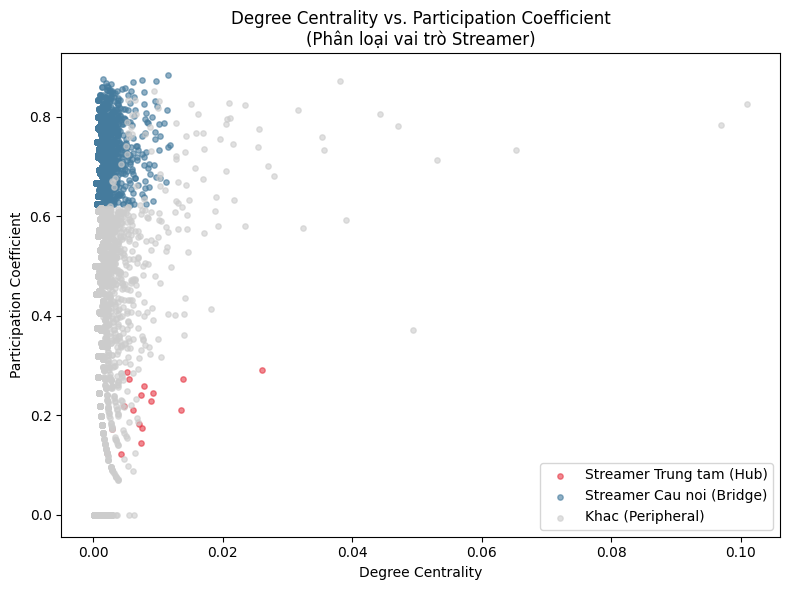

In [ ]:
# Scatter plot: Degree Centrality vs Participation Coefficient (Muc 4.4)
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"Streamer Trung tam (Hub)": "#e63946",
          "Streamer Cau noi (Bridge)": "#457b9d",
          "Khac (Peripheral)": "#cccccc"}
for role, color in colors.items():
    sub = role_df[role_df["role"] == role]
    ax.scatter(sub["degree_centrality"], sub["participation_coefficient"],
                s=15, alpha=0.6, label=role, color=color)
ax.set_xlabel("Degree Centrality")
ax.set_ylabel("Participation Coefficient")
ax.set_title("Degree Centrality vs. Participation Coefficient\n(Phân loại vai trò Streamer)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Attribute Alignment / Homophily

Phần này tách hai loại thuộc tính:

1. **`mature` (categorical)**: đo homophily bằng **Attribute Assortativity Coefficient** trên network. Baseline được tạo bằng cách **shuffle nhãn `mature` trên cùng graph** nhiều lần, nhờ đó giữ nguyên cấu trúc mạng và tỷ lệ nhãn.
2. **`views` (continuous)**: không gọi trực tiếp là homophily. Dùng **eta-squared ($\eta^2$)** trên `log1p(views)` để đo tỷ lệ phương sai views được giải thích bởi Louvain community. Baseline là random partitions bảo toàn community-size profile.

Diễn giải:
- Assortativity > baseline: các node có cùng thuộc tính `mature` có xu hướng kết nối với nhau nhiều hơn ngẫu nhiên.
- $\eta^2$ cao hơn baseline: community membership gắn với sự khác biệt về mức views mạnh hơn phân hoạch ngẫu nhiên.


In [ ]:
def mature_assortativity(G, mature_map):
    H = G.copy()
    nx.set_node_attributes(H, {n: str(bool(v)) for n, v in mature_map.items()}, "mature_eval")
    return float(nx.attribute_assortativity_coefficient(H, "mature_eval"))


def eta_squared_by_group(df, value_col, group_col):
    """One-way ANOVA effect size eta^2 = SS_between / SS_total."""
    values = df[value_col].astype(float)
    grand_mean = values.mean()
    ss_total = float(((values - grand_mean) ** 2).sum())
    if ss_total == 0:
        return 0.0
    ss_between = 0.0
    for _, sub in df.groupby(group_col):
        ss_between += len(sub) * (sub[value_col].mean() - grand_mean) ** 2
    return float(ss_between / ss_total)


align_df = target.rename(columns={"new_id": "node"}).merge(
    pd.DataFrame({
        "node": list(node_to_comm.keys()),
        "louvain_community": list(node_to_comm.values())
    }),
    on="node", how="inner"
)
align_df["log_views"] = np.log1p(align_df["views"].clip(lower=0))

# ------------------------------------------------------------
# A. mature: assortativity + permutation baseline
# ------------------------------------------------------------
mature_map = align_df.set_index("node")["mature"].to_dict()
mature_assort_real = mature_assortativity(G, mature_map)

N_ATTRIBUTE_PERMUTATIONS = 100
rng = np.random.default_rng(RANDOM_SEED)
nodes_order = align_df["node"].to_numpy()
mature_values = align_df["mature"].to_numpy()
mature_perm_scores = []

for i in range(N_ATTRIBUTE_PERMUTATIONS):
    shuffled = rng.permutation(mature_values)
    shuffled_map = dict(zip(nodes_order, shuffled))
    mature_perm_scores.append(mature_assortativity(G, shuffled_map))

mature_perm_mean = float(np.mean(mature_perm_scores))
mature_perm_std = float(np.std(mature_perm_scores, ddof=1))
mature_z = (
    (mature_assort_real - mature_perm_mean) / mature_perm_std
    if mature_perm_std > 0 else np.nan
)

# ------------------------------------------------------------
# B. views: eta^2 theo Louvain community + random-partition baseline
# ------------------------------------------------------------
views_eta_real = eta_squared_by_group(align_df, "log_views", "louvain_community")

views_random_eta = []
for i in range(N_ATTRIBUTE_PERMUTATIONS):
    random_comms, _ = run_random_partition_like(
        G, louvain_comms, seed=RANDOM_SEED + i
    )
    node_to_random = {}
    for cid, nodes in enumerate(random_comms):
        for n in nodes:
            node_to_random[n] = cid
    tmp = align_df[["node", "log_views"]].copy()
    tmp["random_community"] = tmp["node"].map(node_to_random)
    views_random_eta.append(
        eta_squared_by_group(tmp, "log_views", "random_community")
    )

views_rand_mean = float(np.mean(views_random_eta))
views_rand_std = float(np.std(views_random_eta, ddof=1))
views_z = (
    (views_eta_real - views_rand_mean) / views_rand_std
    if views_rand_std > 0 else np.nan
)

alignment_result = pd.DataFrame([
    {
        "Thuoc tinh": "mature",
        "Metric": "Attribute assortativity",
        "Observed": round(mature_assort_real, 4),
        "Random mean": round(mature_perm_mean, 4),
        "Random std": round(mature_perm_std, 4),
        "Z vs Random": round(mature_z, 3) if np.isfinite(mature_z) else np.nan,
    },
    {
        "Thuoc tinh": "log1p(views)",
        "Metric": "Community eta-squared",
        "Observed": round(views_eta_real, 4),
        "Random mean": round(views_rand_mean, 4),
        "Random std": round(views_rand_std, 4),
        "Z vs Random": round(views_z, 3) if np.isfinite(views_z) else np.nan,
    },
])

attribute_baseline_df = pd.DataFrame({
    "iteration": np.arange(1, N_ATTRIBUTE_PERMUTATIONS + 1),
    "mature_assortativity_random": mature_perm_scores,
    "views_eta_squared_random": views_random_eta,
})

print("KET QUA ATTRIBUTE ALIGNMENT / HOMOPHILY")
display(alignment_result)


KET QUA ATTRIBUTE ALIGNMENT / HOMOPHILY


,Thuoc tinh,Metric,Observed,Random mean,Random std,Z vs Random
0,mature,Attribute assortativity,0.0852,-0.0019,0.0048,18.017
1,log1p(views),Community eta-squared,0.0150,0.0022,0.0009,13.446


## 6. Thử nghiệm Phân mảnh Mạng — Hub vs Bridge vs Random Baseline

Giữ nguyên classification strict theo literature, kể cả khi chỉ có **17 Provincial Hubs**.

Ba kịch bản được so sánh với **cùng số node bị xóa**:
- **A — Provincial Hub removal**: xóa các Hub đã classify theo `z_within_degree` giảm dần.
- **B — Community Bridge removal**: xóa các Bridge đã classify theo `betweenness_centrality` giảm dần; Participation Coefficient đã được dùng để xác định membership của nhóm Bridge.
- **C — Random removal baseline**: tại mỗi lần lặp, chọn ngẫu nhiên node từ toàn network và xóa cùng số node như A/B.

Do tập Provincial Hub là nhóm nhỏ nhất, các mốc mặc định là `5, 10, 15` và toàn bộ số Hub hiện có (dự kiến là `17`). Không hạ threshold chỉ để tăng số Hub.

### Random baseline và statistical test

Random removal được lặp nhiều lần (`N_RANDOM_ROBUSTNESS = 500` mặc định; có thể tăng lên 1000 nếu thời gian chạy cho phép). Với mỗi mốc xóa, notebook tính:
- mean, standard deviation và 95% empirical interval của random baseline;
- **empirical one-sided permutation p-value** cho Hub và Bridge so với random.

Hướng kiểm định:
- `LCC/N0`: giá trị **thấp hơn** random = network bị phá mạnh hơn.
- `Fragmentation F`: giá trị **cao hơn** random = network bị phá mạnh hơn.
- `Number of connected components`: giá trị **cao hơn** random = network bị phân mảnh mạnh hơn.

Empirical p-value:
$$p = \frac{1 + \#(\text{random outcomes at least as extreme as targeted})}{B + 1}$$

Theo dõi:
- Largest Connected Component (LCC) và `LCC/N0`.
- Number of Connected Components.
- Fragmentation index:
$$F = 1 - \frac{\sum_i s_i(s_i-1)}{N(N-1)}$$

Không giả định trước Hub hay Bridge phải quan trọng hơn. Trước hết cần chứng minh targeted removal gây tác động lớn hơn **random node failure**; sau đó mới so sánh magnitude giữa Hub và Bridge.


In [ ]:
def fragmentation_index(G):
    N = G.number_of_nodes()
    if N <= 1:
        return 0.0
    comp_sizes = [len(c) for c in nx.connected_components(G)]
    numerator = sum(s * (s - 1) for s in comp_sizes)
    return 1 - numerator / (N * (N - 1))


def lcc_size(G):
    if G.number_of_nodes() == 0:
        return 0
    return max((len(c) for c in nx.connected_components(G)), default=0)


def make_equal_removal_counts(n_hubs, n_bridges):
    max_equal = min(n_hubs, n_bridges)
    if max_equal <= 0:
        return []
    preferred = [5, 10, 15]
    counts = [c for c in preferred if c <= max_equal]
    if max_equal not in counts:
        counts.append(max_equal)
    return sorted(set(counts))


def network_metrics(G_work, N0):
    current_lcc = lcc_size(G_work)
    return {
        "Kich thuoc LCC": current_lcc,
        "Ty le LCC/N_goc": current_lcc / N0,
        "So thanh phan lien thong": nx.number_connected_components(G_work),
        "Chi so Phan manh F": fragmentation_index(G_work),
    }


def run_removal_scenario(G_original, ranked_nodes, removal_counts, scenario_name):
    N0 = G_original.number_of_nodes()
    G_work = G_original.copy()

    base = network_metrics(G_work, N0)
    results = [{
        "Kich ban": scenario_name,
        "So nut bi xoa": 0,
        "Ty le nut bi xoa tren toan mang (%)": 0.0,
        **base,
    }]

    removed_so_far = 0
    for target_removed in removal_counts:
        nodes_to_remove = ranked_nodes[removed_so_far:target_removed]
        G_work.remove_nodes_from(nodes_to_remove)
        removed_so_far = target_removed

        metrics = network_metrics(G_work, N0)
        results.append({
            "Kich ban": scenario_name,
            "So nut bi xoa": removed_so_far,
            "Ty le nut bi xoa tren toan mang (%)": 100 * removed_so_far / N0,
            **metrics,
        })

    return results


def run_random_removal_baseline(G_original, removal_counts, n_iterations=500, seed=42):
    rng = np.random.default_rng(seed)
    all_nodes = np.array(list(G_original.nodes()))
    N0 = G_original.number_of_nodes()
    records = []

    for iteration in range(1, n_iterations + 1):
        random_order = rng.permutation(all_nodes).tolist()
        G_work = G_original.copy()
        removed_so_far = 0

        for target_removed in removal_counts:
            nodes_to_remove = random_order[removed_so_far:target_removed]
            G_work.remove_nodes_from(nodes_to_remove)
            removed_so_far = target_removed

            metrics = network_metrics(G_work, N0)
            records.append({
                "iteration": iteration,
                "So nut bi xoa": target_removed,
                **metrics,
            })

        if iteration % 100 == 0:
            print(f"  Random baseline: {iteration}/{n_iterations} iterations")

    return pd.DataFrame(records)


def summarize_random_baseline(random_df):
    metrics = [
        "Ty le LCC/N_goc",
        "So thanh phan lien thong",
        "Chi so Phan manh F",
    ]
    rows = []

    for n_removed, sub in random_df.groupby("So nut bi xoa"):
        row = {"So nut bi xoa": int(n_removed)}
        for metric in metrics:
            values = sub[metric].astype(float).to_numpy()
            row[f"{metric} - Random mean"] = np.mean(values)
            row[f"{metric} - Random std"] = np.std(values, ddof=1)
            row[f"{metric} - Random CI2.5"] = np.quantile(values, 0.025)
            row[f"{metric} - Random CI97.5"] = np.quantile(values, 0.975)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("So nut bi xoa")


def empirical_one_sided_p(targeted_value, random_values, direction):
    random_values = np.asarray(random_values, dtype=float)
    B = len(random_values)

    if direction == "lower":
        extreme = np.sum(random_values <= targeted_value)
    elif direction == "higher":
        extreme = np.sum(random_values >= targeted_value)
    else:
        raise ValueError("direction phai la 'lower' hoac 'higher'")

    return (extreme + 1) / (B + 1)


def targeted_vs_random_tests(targeted_df, random_df):
    metric_directions = {
        "Ty le LCC/N_goc": "lower",
        "So thanh phan lien thong": "higher",
        "Chi so Phan manh F": "higher",
    }

    rows = []
    targeted_nonzero = targeted_df[targeted_df["So nut bi xoa"] > 0].copy()

    for _, r in targeted_nonzero.iterrows():
        scenario = r["Kich ban"]
        n_removed = int(r["So nut bi xoa"])
        random_sub = random_df[random_df["So nut bi xoa"] == n_removed]

        for metric, direction in metric_directions.items():
            target_value = float(r[metric])
            random_values = random_sub[metric].astype(float).to_numpy()
            random_mean = float(np.mean(random_values))
            random_std = float(np.std(random_values, ddof=1))

            p = empirical_one_sided_p(
                target_value,
                random_values,
                direction=direction,
            )

            if random_std > 0:
                if direction == "higher":
                    z_effect = (target_value - random_mean) / random_std
                else:
                    z_effect = (random_mean - target_value) / random_std
            else:
                z_effect = np.nan

            rows.append({
                "Kich ban": scenario,
                "So nut bi xoa": n_removed,
                "Metric": metric,
                "Targeted value": target_value,
                "Random mean": random_mean,
                "Random std": random_std,
                "Effect z vs Random (positive=more disruptive)": z_effect,
                "Empirical one-sided p": p,
                "Significant at 0.05": p < 0.05,
            })

    return pd.DataFrame(rows)


hub_pool = role_df[role_df["role"] == "Streamer Trung tam (Hub)"].copy()
bridge_pool = role_df[role_df["role"] == "Streamer Cau noi (Bridge)"].copy()

ranked_hubs = (
    hub_pool
    .sort_values(["z_within_degree", "degree_raw"], ascending=False)["node"]
    .tolist()
)

ranked_bridges = (
    bridge_pool
    .sort_values(
        ["betweenness_centrality", "participation_coefficient"],
        ascending=False,
    )["node"]
    .tolist()
)

REMOVAL_COUNTS = make_equal_removal_counts(
    len(ranked_hubs),
    len(ranked_bridges),
)

print(f"So Provincial Hubs: {len(ranked_hubs)}")
print(f"So Community Bridges: {len(ranked_bridges)}")
print(f"Cac moc xoa bang nhau: {REMOVAL_COUNTS}")

if not REMOVAL_COUNTS:
    raise ValueError(
        "Khong du Hub hoac Bridge theo strict role classification de chay robustness."
    )

print("\n>>> [Kich ban A] Xoa Provincial Hubs da classify...")
results_A = run_removal_scenario(
    G,
    ranked_hubs,
    REMOVAL_COUNTS,
    "A: Xoa Provincial Hub",
)

print(">>> [Kich ban B] Xoa Community Bridges da classify...")
results_B = run_removal_scenario(
    G,
    ranked_bridges,
    REMOVAL_COUNTS,
    "B: Xoa Community Bridge",
)

targeted_robustness_df = pd.DataFrame(results_A + results_B)

N_RANDOM_ROBUSTNESS = 500
print(
    f"\n>>> [Kich ban C] Random removal baseline: "
    f"{N_RANDOM_ROBUSTNESS} iterations..."
)

random_robustness_raw_df = run_random_removal_baseline(
    G,
    REMOVAL_COUNTS,
    n_iterations=N_RANDOM_ROBUSTNESS,
    seed=RANDOM_SEED,
)

random_robustness_summary_df = summarize_random_baseline(
    random_robustness_raw_df
)

robustness_stat_test_df = targeted_vs_random_tests(
    targeted_robustness_df,
    random_robustness_raw_df,
)

robustness_df = targeted_robustness_df.copy()

print("\nKET QUA TARGETED ROBUSTNESS")
display(targeted_robustness_df)

print("\nRANDOM BASELINE SUMMARY (mean, SD, empirical 95% interval)")
display(random_robustness_summary_df)

print("\nEMPIRICAL ONE-SIDED PERMUTATION TESTS: TARGETED vs RANDOM")
display(robustness_stat_test_df)


So Provincial Hubs: 17
So Community Bridges: 1960
Cac moc xoa bang nhau: [5, 10, 15, 17]

>>> [Kich ban A] Xoa Provincial Hubs da classify...
>>> [Kich ban B] Xoa Community Bridges da classify...

>>> [Kich ban C] Random removal baseline: 500 iterations...
  Random baseline: 100/500 iterations
  Random baseline: 200/500 iterations
  Random baseline: 300/500 iterations
  Random baseline: 400/500 iterations
  Random baseline: 500/500 iterations

KET QUA TARGETED ROBUSTNESS


,Kich ban,So nut bi xoa,Ty le nut bi xoa tren toan mang (%),Kich thuoc LCC,Ty le LCC/N_goc,So thanh phan lien thong,Chi so Phan manh F
0,A: Xoa Provincial Hub,0,0.000000,7126,1.000000,1,0.000000
1,A: Xoa Provincial Hub,5,0.070166,7111,0.997895,10,0.002807
2,A: Xoa Provincial Hub,10,0.140331,7106,0.997193,10,0.002809
3,A: Xoa Provincial Hub,15,0.210497,7095,0.995650,16,0.004495
4,A: Xoa Provincial Hub,17,0.238563,7092,0.995229,17,0.004777
5,B: Xoa Community Bridge,0,0.000000,7126,1.000000,1,0.000000
6,B: Xoa Community Bridge,5,0.070166,7111,0.997895,11,0.002807
7,B: Xoa Community Bridge,10,0.140331,7091,0.995088,26,0.007015
8,B: Xoa Community Bridge,15,0.210497,7081,0.993685,31,0.008420
9,B: Xoa Community Bridge,17,0.238563,7078,0.993264,32,0.008703



RANDOM BASELINE SUMMARY (mean, SD, empirical 95% interval)


,So nut bi xoa,Ty le LCC/N_goc - Random mean,Ty le LCC/N_goc - Random std,Ty le LCC/N_goc - Random CI2.5,Ty le LCC/N_goc - Random CI97.5,So thanh phan lien thong - Random mean,So thanh phan lien thong - Random std,So thanh phan lien thong - Random CI2.5,So thanh phan lien thong - Random CI97.5,Chi so Phan manh F - Random mean,Chi so Phan manh F - Random std,Chi so Phan manh F - Random CI2.5,Chi so Phan manh F - Random CI97.5
0,5,0.999183,0.000281,0.998737,0.999298,1.784,1.896454,1.0,5.0,0.000231,0.000561,0.0,0.001123
1,10,0.998337,0.000504,0.997400,0.998597,2.760,3.381311,1.0,9.0,0.000520,0.001007,0.0,0.002395
2,15,0.997499,0.000667,0.996351,0.997895,3.668,4.448523,1.0,11.0,0.000794,0.001334,0.0,0.003092
3,17,0.997163,0.000697,0.995930,0.997614,4.028,4.640937,1.0,12.0,0.000904,0.001393,0.0,0.003373



EMPIRICAL ONE-SIDED PERMUTATION TESTS: TARGETED vs RANDOM


,Kich ban,So nut bi xoa,Metric,Targeted value,Random mean,Random std,Effect z vs Random (positive=more disruptive),Empirical one-sided p,Significant at 0.05
0,A: Xoa Provincial Hub,5,Ty le LCC/N_goc,0.997895,0.999183,0.000281,4.585374,0.005988,True
1,A: Xoa Provincial Hub,5,So thanh phan lien thong,10.000000,1.784000,1.896454,4.332296,0.005988,True
2,A: Xoa Provincial Hub,5,Chi so Phan manh F,0.002807,0.000231,0.000561,4.589962,0.005988,True
3,A: Xoa Provincial Hub,10,Ty le LCC/N_goc,0.997193,0.998337,0.000504,2.269386,0.015968,True
4,A: Xoa Provincial Hub,10,So thanh phan lien thong,10.000000,2.760000,3.381311,2.141181,0.019960,True
5,A: Xoa Provincial Hub,10,Chi so Phan manh F,0.002809,0.000520,0.001007,2.273139,0.015968,True
6,A: Xoa Provincial Hub,15,Ty le LCC/N_goc,0.995650,0.997499,0.000667,2.770719,0.017964,True
7,A: Xoa Provincial Hub,15,So thanh phan lien thong,16.000000,3.668000,4.448523,2.772156,0.017964,True
8,A: Xoa Provincial Hub,15,Chi so Phan manh F,0.004495,0.000794,0.001334,2.775241,0.017964,True
9,A: Xoa Provincial Hub,17,Ty le LCC/N_goc,0.995229,0.997163,0.000697,2.777185,0.019960,True


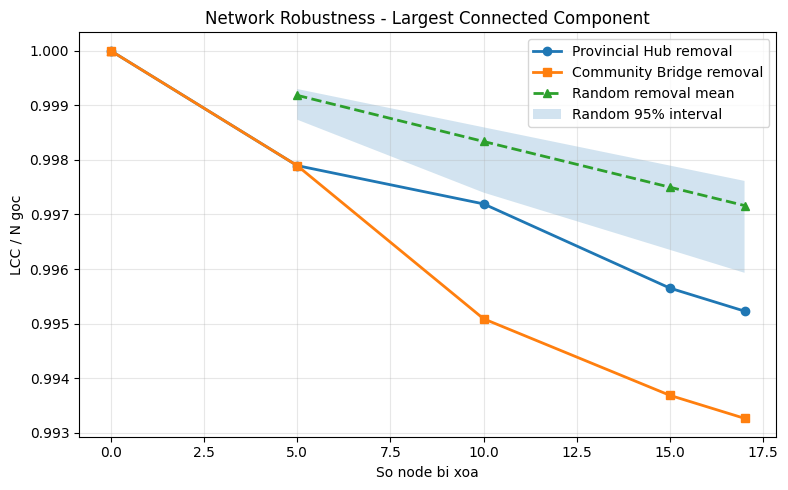

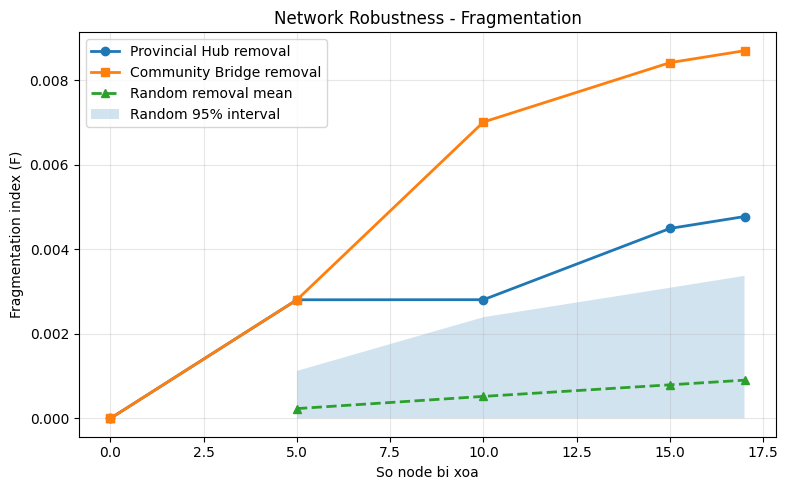

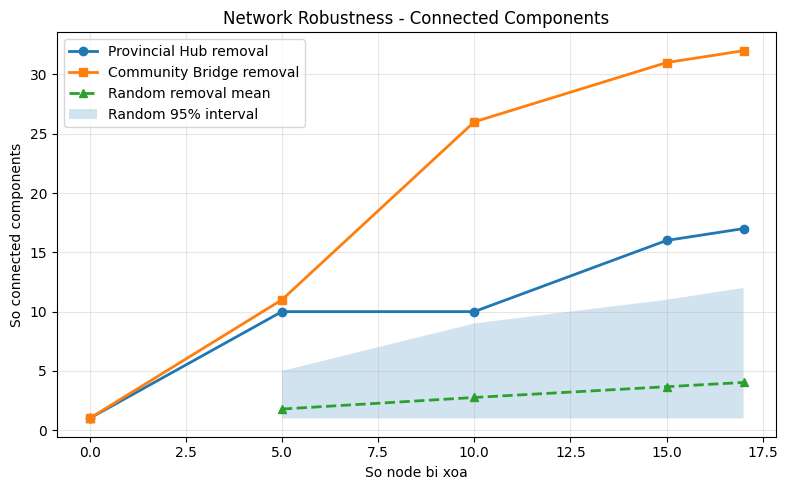

BANG STATISTICAL TEST TOM TAT


,Kich ban,So nut bi xoa,Metric,Effect z vs Random (positive=more disruptive),Empirical one-sided p,Significant at 0.05
0,A: Xoa Provincial Hub,5,Ty le LCC/N_goc,4.585374,0.005988,True
1,A: Xoa Provincial Hub,5,So thanh phan lien thong,4.332296,0.005988,True
2,A: Xoa Provincial Hub,5,Chi so Phan manh F,4.589962,0.005988,True
3,A: Xoa Provincial Hub,10,Ty le LCC/N_goc,2.269386,0.015968,True
4,A: Xoa Provincial Hub,10,So thanh phan lien thong,2.141181,0.019960,True
5,A: Xoa Provincial Hub,10,Chi so Phan manh F,2.273139,0.015968,True
6,A: Xoa Provincial Hub,15,Ty le LCC/N_goc,2.770719,0.017964,True
7,A: Xoa Provincial Hub,15,So thanh phan lien thong,2.772156,0.017964,True
8,A: Xoa Provincial Hub,15,Chi so Phan manh F,2.775241,0.017964,True
9,A: Xoa Provincial Hub,17,Ty le LCC/N_goc,2.777185,0.019960,True


In [ ]:
targeted_scenarios = [
    ("A: Xoa Provincial Hub", "o", "Provincial Hub removal"),
    ("B: Xoa Community Bridge", "s", "Community Bridge removal"),
]

def plot_robustness_with_random(
    targeted_df,
    random_summary_df,
    metric,
    random_mean_col,
    random_low_col,
    random_high_col,
    ylabel,
    title,
):
    fig, ax = plt.subplots(figsize=(8, 5))

    for scenario, marker, label in targeted_scenarios:
        sub = targeted_df[targeted_df["Kich ban"] == scenario]
        ax.plot(
            sub["So nut bi xoa"],
            sub[metric],
            marker=marker,
            linewidth=2,
            label=label,
        )

    x = random_summary_df["So nut bi xoa"].to_numpy()
    mean = random_summary_df[random_mean_col].to_numpy()
    low = random_summary_df[random_low_col].to_numpy()
    high = random_summary_df[random_high_col].to_numpy()

    ax.plot(
        x,
        mean,
        marker="^",
        linestyle="--",
        linewidth=2,
        label="Random removal mean",
    )
    ax.fill_between(
        x,
        low,
        high,
        alpha=0.20,
        label="Random 95% interval",
    )

    if metric == "Ty le LCC/N_goc":
        ax.scatter([0], [1.0], marker="^")
    elif metric == "Chi so Phan manh F":
        ax.scatter([0], [0.0], marker="^")
    elif metric == "So thanh phan lien thong":
        ax.scatter([0], [1], marker="^")

    ax.set_xlabel("So node bi xoa")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_robustness_with_random(
    targeted_robustness_df,
    random_robustness_summary_df,
    metric="Ty le LCC/N_goc",
    random_mean_col="Ty le LCC/N_goc - Random mean",
    random_low_col="Ty le LCC/N_goc - Random CI2.5",
    random_high_col="Ty le LCC/N_goc - Random CI97.5",
    ylabel="LCC / N goc",
    title="Network Robustness - Largest Connected Component",
)

plot_robustness_with_random(
    targeted_robustness_df,
    random_robustness_summary_df,
    metric="Chi so Phan manh F",
    random_mean_col="Chi so Phan manh F - Random mean",
    random_low_col="Chi so Phan manh F - Random CI2.5",
    random_high_col="Chi so Phan manh F - Random CI97.5",
    ylabel="Fragmentation index (F)",
    title="Network Robustness - Fragmentation",
)

plot_robustness_with_random(
    targeted_robustness_df,
    random_robustness_summary_df,
    metric="So thanh phan lien thong",
    random_mean_col="So thanh phan lien thong - Random mean",
    random_low_col="So thanh phan lien thong - Random CI2.5",
    random_high_col="So thanh phan lien thong - Random CI97.5",
    ylabel="So connected components",
    title="Network Robustness - Connected Components",
)

robustness_pvalue_table = robustness_stat_test_df[
    [
        "Kich ban",
        "So nut bi xoa",
        "Metric",
        "Effect z vs Random (positive=more disruptive)",
        "Empirical one-sided p",
        "Significant at 0.05",
    ]
].copy()

print("BANG STATISTICAL TEST TOM TAT")
display(robustness_pvalue_table)


### Cách diễn giải robustness và statistical test

Thứ tự diễn giải nên là:

1. **Targeted vs Random:** kiểm tra Hub removal và Bridge removal có gây disruption lớn hơn random node failure hay không.
2. Chỉ khi một targeted scenario vượt random một cách nhất quán mới diễn giải sâu hơn về vai trò cấu trúc.
3. Sau đó mới so sánh **magnitude** Hub vs Bridge tại cùng số node bị xóa.

Với empirical one-sided test:
- `p < 0.05`: targeted removal gây disruption mạnh hơn random ở metric/mốc đó.
- `p >= 0.05`: chưa đủ bằng chứng để nói targeted removal khác random ở metric/mốc đó.
- `Effect z vs Random > 0`: targeted removal disruptive hơn random; trị tuyệt đối càng lớn thì khoảng cách so với null distribution càng rõ.

Không dùng p-value để nói trực tiếp “Bridge khác Hub có ý nghĩa thống kê”, vì mỗi targeted attack hiện là một ranking deterministic. Statistical test trong notebook kiểm định **từng targeted role so với random-removal null model**.

Nếu Bridge removal có `p < 0.05` nhất quán trên LCC, Fragmentation và Components, trong khi Hub yếu hơn hoặc không significant, có thể kết luận thận trọng rằng **inter-community connector nodes có tác động tới global connectivity vượt quá random failure mạnh hơn Provincial Hubs tại các attack sizes được thử**.

Nếu cả Hub và Bridge đều significant so với random nhưng Bridge có effect size lớn hơn, kết luận phù hợp là **cả hai đều structurally important, nhưng Bridge tạo global disruption lớn hơn trong matched removal experiment**.

Do strict definition chỉ tạo một số lượng nhỏ Provincial Hubs, robustness được giới hạn ở các small-scale targeted attacks. Đây là limitation của thiết kế, không phải lý do để hạ threshold chỉ nhằm tăng số Hub.


## 7. Trực quan hóa Mạng lưới: NetworkX + Gephi + Cytoscape

### 7.1 NetworkX
Dùng NetworkX/Matplotlib cho:
- Network overview theo Louvain community + PageRank.
- Hub / Bridge / Peripheral visualization.
- Robustness curves.

### 7.2 Gephi
Xuất GraphML/GEXF để dùng **Gephi** với ForceAtlas2, Statistics và Partition.
Gephi phù hợp hơn cho hình mạng 7,126 nodes vì layout và rendering tốt hơn Matplotlib.

### 7.3 Cytoscape
Xuất node/edge CSV để có thể import vào **Cytoscape**.
Cytoscape phù hợp khi muốn style node theo thuộc tính và khám phá từng community.

**Khuyến nghị cho report:** dùng Gephi cho hình network tổng thể; dùng NetworkX cho các
biểu đồ định lượng; dùng Cytoscape nếu cần zoom/khám phá các community hoặc vai trò node.


Dang tinh layout NetworkX...


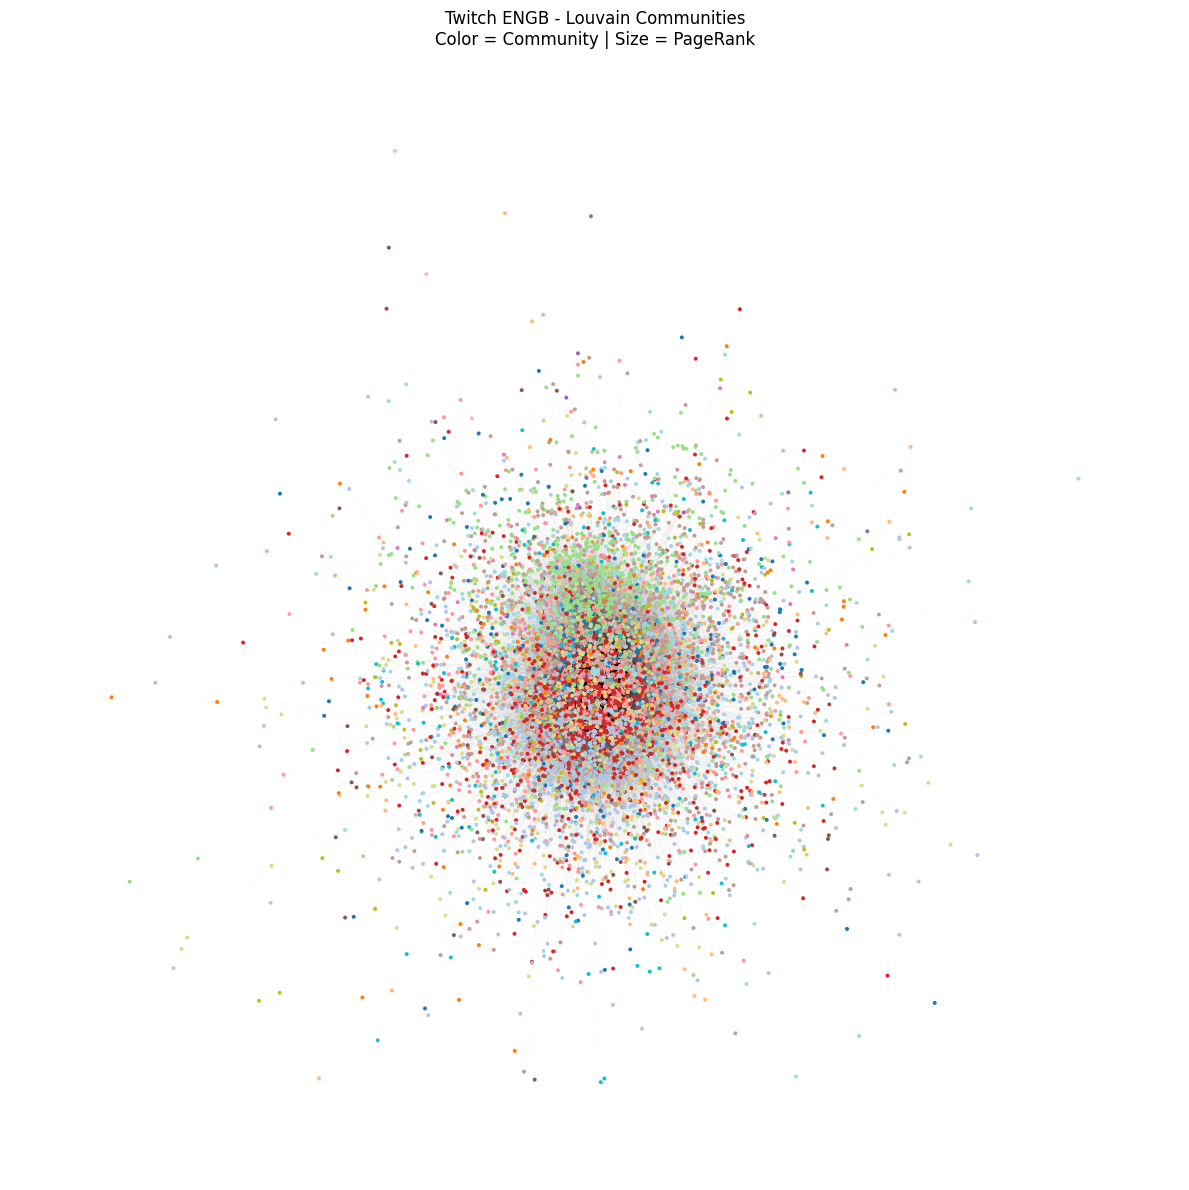

In [ ]:
# ============================================================
# 7.1 NETWORKX - Community Overview
# ============================================================

# Spring layout có thể tốn thời gian trên 7,126 nodes.
# Dùng seed để kết quả tái lập được.
print("Dang tinh layout NetworkX...")
pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.08, iterations=80)

fig, ax = plt.subplots(figsize=(12, 12))

role_df_idx = role_df.set_index("node")
communities_series = role_df_idx["louvain_community"]
n_comm = communities_series.nunique()

cmap = plt.get_cmap("tab20", n_comm)
node_colors = [cmap(int(communities_series.loc[n]) % 20) for n in G.nodes()]

pagerank_vals = role_df_idx["pagerank"]
node_sizes = [8 + 4000 * pagerank_vals.loc[n] for n in G.nodes()]

nx.draw_networkx_edges(
    G, pos, ax=ax,
    alpha=0.025, width=0.35
)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    linewidths=0
)

ax.set_title(
    "Twitch ENGB - Louvain Communities\n"
    "Color = Community | Size = PageRank"
)
ax.axis("off")
plt.tight_layout()
plt.show()


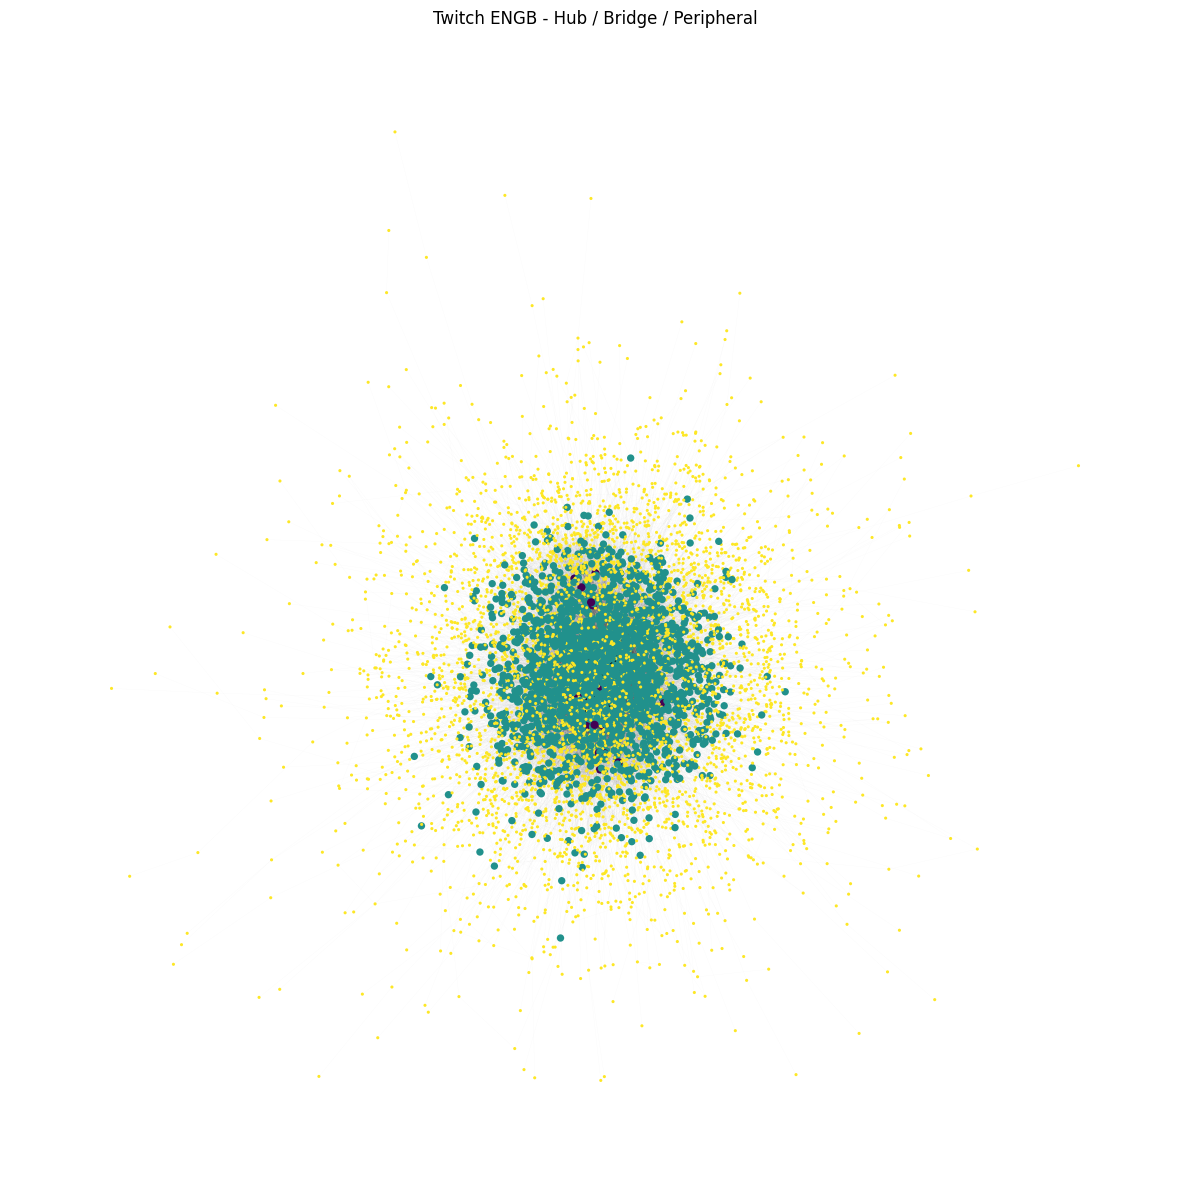

Da xuat file cho Gephi:
  outputs/twitch_community_network.graphml
  outputs/twitch_community_network.gexf

Da xuat file cho Cytoscape:
  outputs/cytoscape_nodes.csv
  outputs/cytoscape_edges.csv


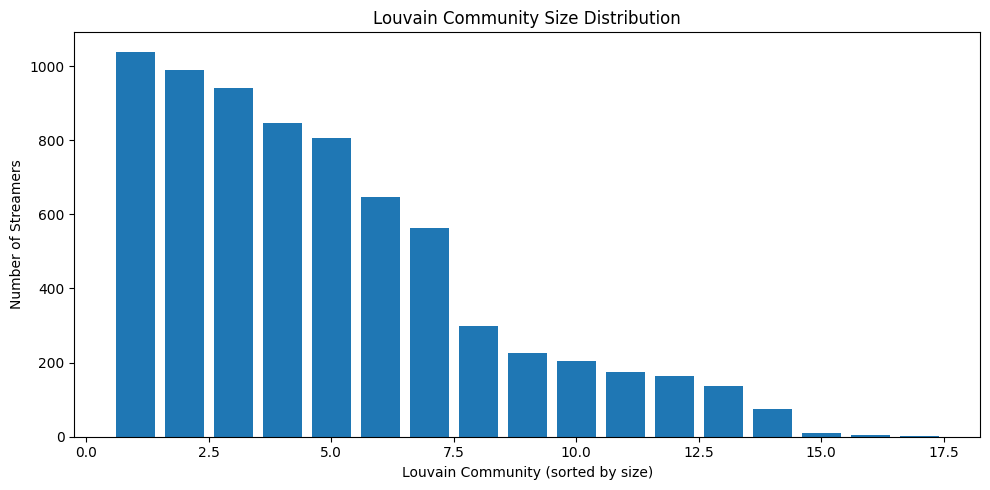

In [ ]:
# ============================================================
# 7.2 NETWORKX - Hub / Bridge / Peripheral
# ============================================================

fig, ax = plt.subplots(figsize=(12, 12))

role_color_map = {
    "Streamer Trung tam (Hub)": 0,
    "Streamer Cau noi (Bridge)": 1,
    "Khac (Peripheral)": 2
}

node_role = role_df_idx["role"].to_dict()
node_colors_role = [
    role_color_map.get(node_role.get(n, "Khac (Peripheral)"), 2)
    for n in G.nodes()
]

# Highlight Hub/Bridge, keep Peripheral very small
node_sizes_role = []
for n in G.nodes():
    role = node_role.get(n, "Khac (Peripheral)")
    if role == "Streamer Trung tam (Hub)":
        node_sizes_role.append(35)
    elif role == "Streamer Cau noi (Bridge)":
        node_sizes_role.append(28)
    else:
        node_sizes_role.append(5)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.018, width=0.3)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors_role,
    node_size=node_sizes_role,
    linewidths=0
)

ax.set_title("Twitch ENGB - Hub / Bridge / Peripheral")
ax.axis("off")
plt.tight_layout()
plt.show()


# ============================================================
# 7.3 NETWORK EXPORT CHO GEphi
# ============================================================

os.makedirs("outputs", exist_ok=True)

# Gốc: toàn bộ graph + các thuộc tính node hiện có
G_export = G.copy()

# Gắn community, role, centrality vào node attributes
role_lookup = role_df.set_index("node")

for node in G_export.nodes():
    if node in role_lookup.index:
        row = role_lookup.loc[node]
        G_export.nodes[node]["louvain_community"] = int(row["louvain_community"])
        G_export.nodes[node]["role"] = str(row["role"])
        G_export.nodes[node]["pagerank"] = float(row["pagerank"])
        G_export.nodes[node]["degree_centrality"] = float(row["degree_centrality"])
        G_export.nodes[node]["betweenness_centrality"] = float(row["betweenness_centrality"])
        G_export.nodes[node]["participation_coefficient"] = float(row["participation_coefficient"])
        G_export.nodes[node]["within_module_z"] = float(row["z_within_degree"])

# GraphML: import trực tiếp vào Gephi
nx.write_graphml(G_export, "outputs/twitch_community_network.graphml")

# GEXF: cũng phù hợp với Gephi
nx.write_gexf(G_export, "outputs/twitch_community_network.gexf")

print("Da xuat file cho Gephi:")
print("  outputs/twitch_community_network.graphml")
print("  outputs/twitch_community_network.gexf")


# ============================================================
# 7.4 CYTOSCAPE - NODE / EDGE CSV
# ============================================================

# Node table
cyto_nodes = role_df.copy()
cyto_nodes.to_csv("outputs/cytoscape_nodes.csv", index=False)

# Edge table: source / target
cyto_edges = nx.to_pandas_edgelist(G)[["source", "target"]]
cyto_edges.to_csv("outputs/cytoscape_edges.csv", index=False)

print("\nDa xuat file cho Cytoscape:")
print("  outputs/cytoscape_nodes.csv")
print("  outputs/cytoscape_edges.csv")


# ============================================================
# 7.5 NETWORKX - Community Size Distribution
# ============================================================

community_sizes = (
    role_df.groupby("louvain_community")
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    range(1, len(community_sizes) + 1),
    community_sizes.values
)
ax.set_xlabel("Louvain Community (sorted by size)")
ax.set_ylabel("Number of Streamers")
ax.set_title("Louvain Community Size Distribution")
plt.tight_layout()
plt.show()


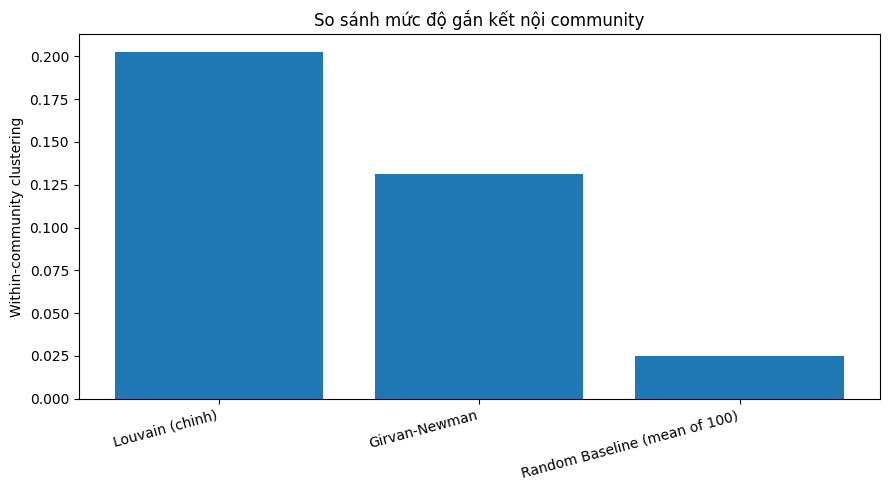

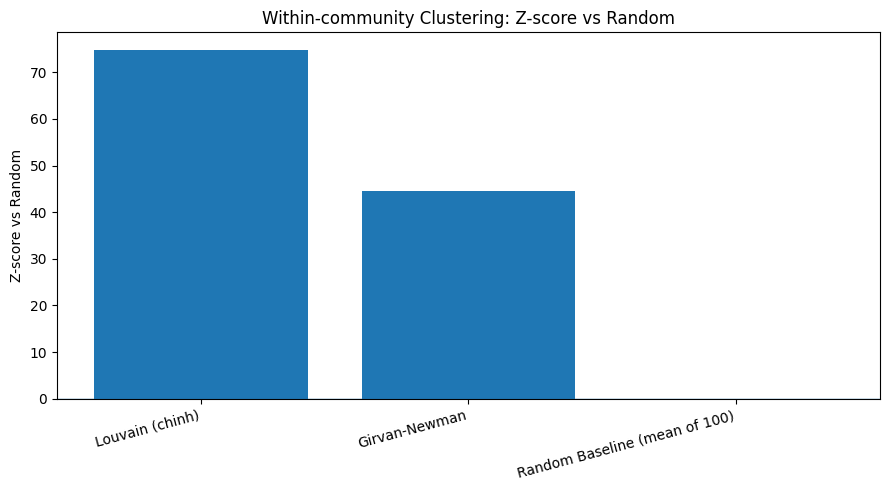

In [ ]:
# ============================================================
# 7.6 VISUAL SO SÁNH COMMUNITY QUALITY
# ============================================================

plot_df = community_comparison.copy()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["Within-community Clustering (weighted)"]
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Phuong phap"], rotation=15, ha="right")
ax.set_ylabel("Within-community clustering")
ax.set_title("So sánh mức độ gắn kết nội community")
plt.tight_layout()
plt.show()

# Z-score plot (Random = 0)
fig, ax = plt.subplots(figsize=(9, 5))
z_vals = plot_df["Z vs Random (Clustering)"].values
ax.bar(x, z_vals)
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Phuong phap"], rotation=15, ha="right")
ax.set_ylabel("Z-score vs Random")
ax.set_title("Within-community Clustering: Z-score vs Random")
plt.tight_layout()
plt.show()


### Ghi chú về network overview

Network overview theo Louvain community đã được vẽ ở Cell 7.1. Không lặp lại cùng một full-network chart ở đây để tránh trùng figure trong paper.


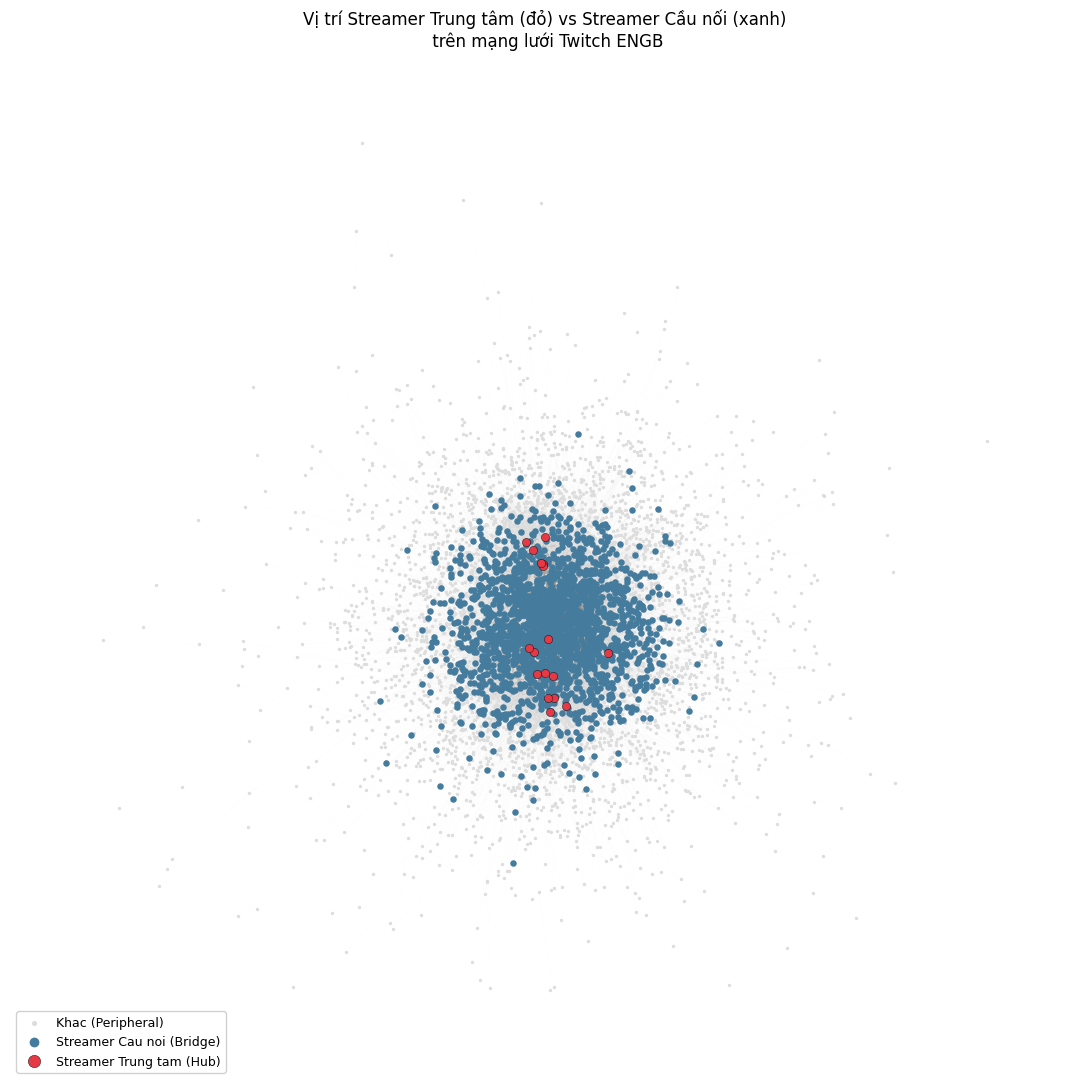

In [ ]:
# HINH 2: Can canh vi tri Streamer Trung tam vs Streamer Cau noi
fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.02, width=0.3, edge_color="gray")

other_nodes = role_df_idx[role_df_idx["role"] == "Khac (Peripheral)"].index.tolist()
hub_nodes = role_df_idx[role_df_idx["role"] == "Streamer Trung tam (Hub)"].index.tolist()
bridge_nodes = role_df_idx[role_df_idx["role"] == "Streamer Cau noi (Bridge)"].index.tolist()

nx.draw_networkx_nodes(G, pos, nodelist=other_nodes, ax=ax, node_color="#dddddd",
                        node_size=6, linewidths=0, label="Khac (Peripheral)")
nx.draw_networkx_nodes(G, pos, nodelist=bridge_nodes, ax=ax, node_color="#457b9d",
                        node_size=22, linewidths=0, label="Streamer Cau noi (Bridge)")
nx.draw_networkx_nodes(G, pos, nodelist=hub_nodes, ax=ax, node_color="#e63946",
                        node_size=35, linewidths=0.3, edgecolors="black",
                        label="Streamer Trung tam (Hub)")

ax.set_title("Vị trí Streamer Trung tâm (đỏ) vs Streamer Cầu nối (xanh)\n trên mạng lưới Twitch ENGB")
ax.axis("off")
ax.legend(scatterpoints=1, markerscale=1.5, loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## Xuất kết quả
Chạy cell dưới để lưu toàn bộ bảng số liệu ra file CSV

In [ ]:
os.makedirs("outputs", exist_ok=True)
df_stats.to_csv("outputs/network_stats.csv", index=False)
centrality_df.to_csv("outputs/centrality.csv", index=False)
community_comparison.to_csv("outputs/community_comparison.csv", index=False)
random_baseline_df.to_csv("outputs/random_community_baseline_100.csv", index=False)
louvain_wc_detail.to_csv("outputs/louvain_within_clustering_by_community.csv", index=False)
gn_wc_detail.to_csv("outputs/gn_within_clustering_by_community.csv", index=False)
role_df.to_csv("outputs/role_classification.csv", index=False)
alignment_result.to_csv("outputs/attribute_alignment.csv", index=False)
attribute_baseline_df.to_csv("outputs/attribute_alignment_random_baseline.csv", index=False)
robustness_df.to_csv("outputs/robustness_results.csv", index=False)

if not betweenness_sensitivity_df.empty:
    betweenness_sensitivity_df.to_csv("outputs/betweenness_sensitivity_scores.csv", index=False)
if not betweenness_overlap_df.empty:
    betweenness_overlap_df.to_csv("outputs/betweenness_sensitivity_top_overlap.csv", index=False)

print("Da luu toan bo bang ket qua vao thu muc outputs/")

# Neu dang chay tren Colab va muon tai file ve may:
from google.colab import files
import shutil
shutil.make_archive("outputs", "zip", "outputs")
files.download("outputs.zip")

random_robustness_raw_df.to_csv("outputs/random_robustness_raw.csv", index=False)
random_robustness_summary_df.to_csv("outputs/random_robustness_summary.csv", index=False)
robustness_stat_test_df.to_csv("outputs/robustness_statistical_tests.csv", index=False)
robustness_pvalue_table.to_csv("outputs/robustness_pvalue_table.csv", index=False)


Da luu toan bo bang ket qua vao thu muc outputs/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Changes

Phiên bản này giữ nguyên strict role classification và bổ sung robustness inference:

- Giữ **Provincial Hub** theo Guimerà & Amaral: `z >= 2.5` và `P <= 0.30`; không hạ threshold chỉ để tăng số Hub.
- Làm rõ **`P > 0.62`**: trong framework gốc, non-hub có `0.62 < P <= 0.80` là **non-hub connector**; `P > 0.80` là kinless non-hub. Notebook operationalize `z < 2.5 & P > 0.62` thành **Community Bridge** trong bối cảnh Twitch để bao quát các non-hub có kết nối liên-community mạnh.
- Robustness dùng matched removal tại các mốc phù hợp với tập Hub nhỏ (`5, 10, 15, max_equal`, dự kiến max = 17).
- Thêm **Random Removal Baseline** chạy 500 lần, giữ cùng số node bị xóa với Hub/Bridge.
- Random baseline báo cáo mean, SD và empirical 95% interval.
- Thêm **empirical one-sided permutation test** cho từng Hub/Bridge scenario so với random null model.
- Thêm standardized effect (`z vs Random`) với quy ước số dương = disruptive hơn random.
- Cập nhật robustness figures để hiển thị Hub, Bridge, Random mean và 95% interval trên cùng biểu đồ.
- Xuất thêm các bảng `random_robustness_*` và `robustness_statistical_tests.csv`.

### Research logic cuối cùng

Data → Network Construction → Community Detection → Community Evaluation → Role Classification → Attribute Analysis → **Hub vs Bridge vs Random Removal** → **Permutation Test / Effect Size** → Robustness Comparison → Conclusion

Không hard-code kết luận. Sau khi sửa, hãy **Run all** để sinh lại toàn bộ output trước khi dùng kết quả trong paper.
